**Import and Read Dataset**

In [56]:
# ============================
# SMART LENDER PROJECT
# Import Required Libraries
# ============================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [57]:
# ============================
# Read Dataset
# ============================

df = pd.read_csv("loan_prediction.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [58]:
# Display First 5 Rows

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [59]:
print("Rows and Columns:")
df.shape

Rows and Columns:


(614, 13)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [61]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [62]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**Univariate Analysis**

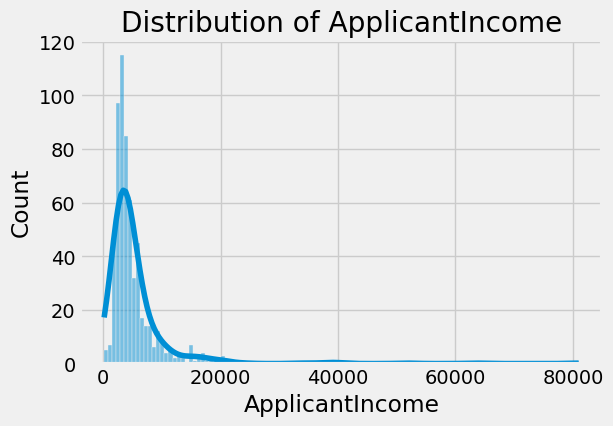

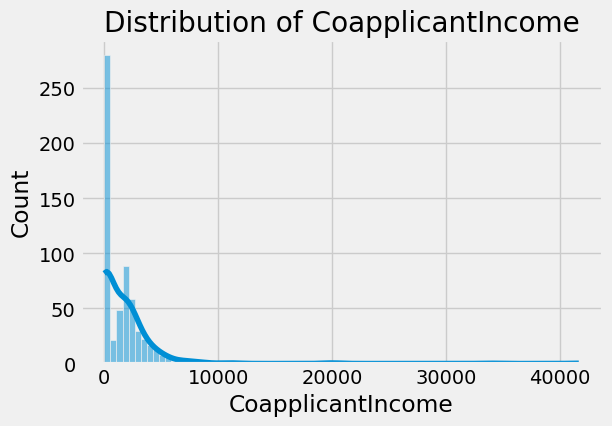

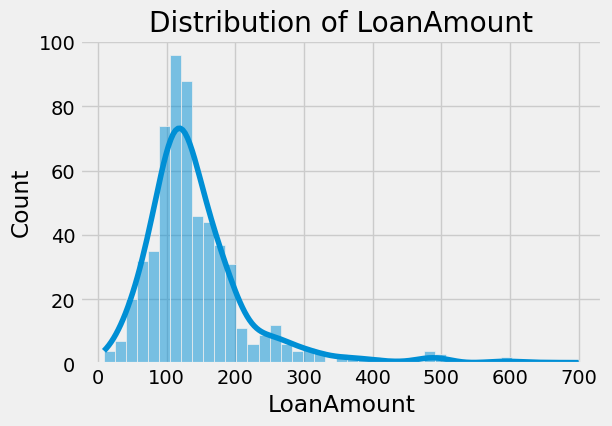

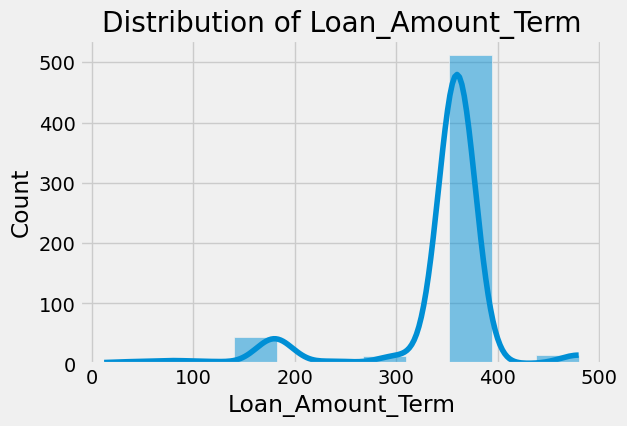

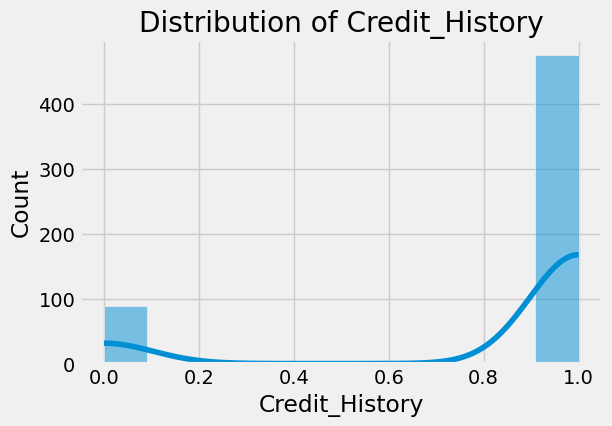

In [63]:
# =====================================
# Univariate Analysis
# =====================================

plt.style.use('fivethirtyeight')

# Numerical Columns
numerical_columns = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

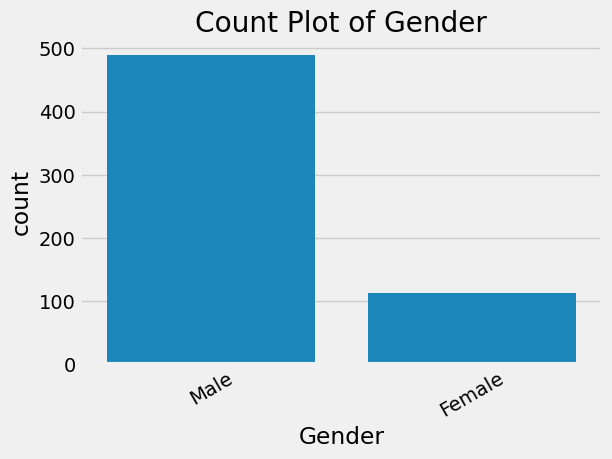

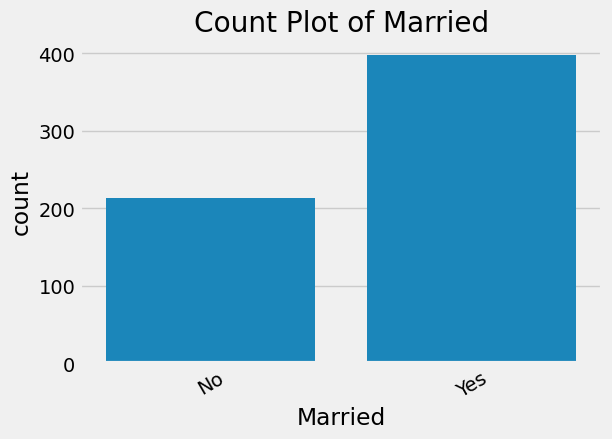

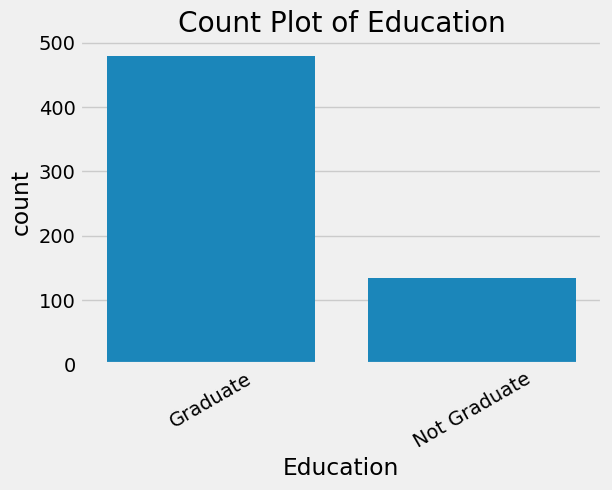

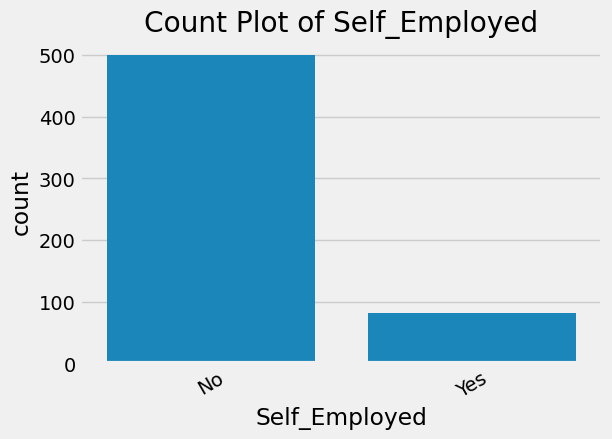

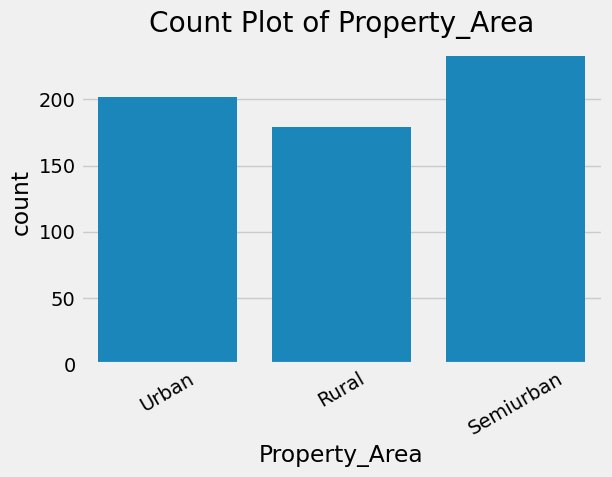

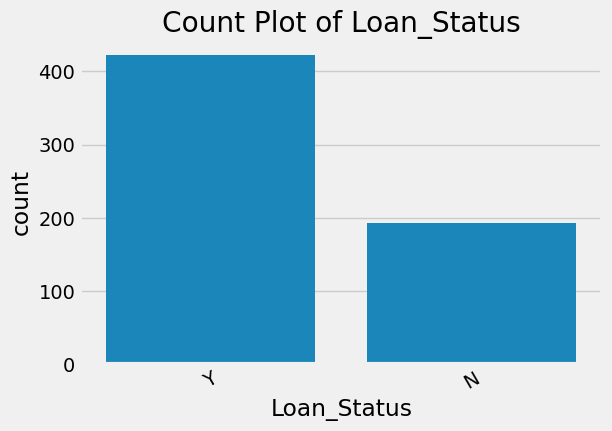

In [64]:
# =====================================
# Count Plots
# =====================================

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=30)
    plt.title(f'Count Plot of {col}')
    plt.show()

Observations

• ApplicantIncome is positively skewed.

• LoanAmount contains a few high-value outliers.

• Credit_History mostly contains values 0 and 1.

• Most applicants are Male.

• Most applicants are Graduates.

• Most applicants are Married.

• Most loans are Approved.

# Bivariate Analysis

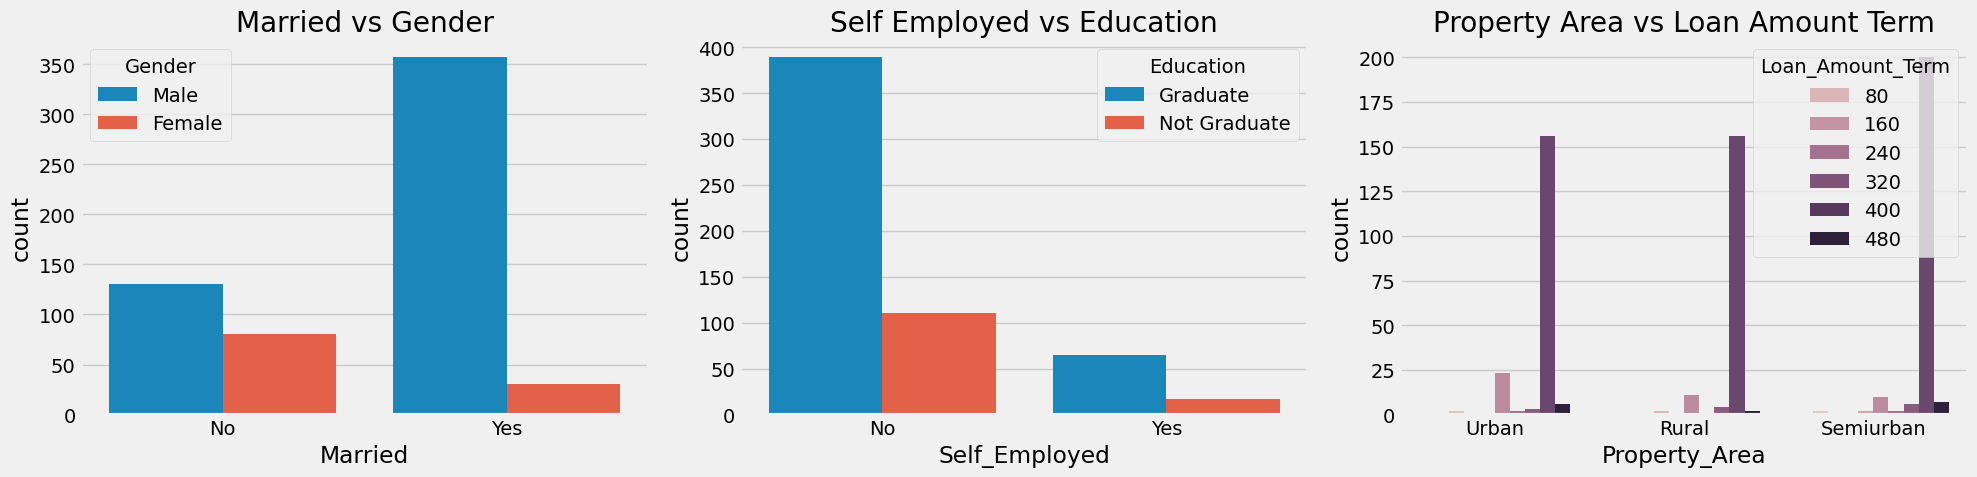

In [65]:
# =====================================
# Bivariate Analysis
# =====================================

plt.figure(figsize=(20,5))

# Married vs Gender
plt.subplot(131)
sns.countplot(data=df, x='Married', hue='Gender')
plt.title("Married vs Gender")

# Self Employed vs Education
plt.subplot(132)
sns.countplot(data=df, x='Self_Employed', hue='Education')
plt.title("Self Employed vs Education")

# Property Area vs Loan Amount Term
plt.subplot(133)
sns.countplot(data=df, x='Property_Area', hue='Loan_Amount_Term')

plt.title("Property Area vs Loan Amount Term")

plt.tight_layout()
plt.show()

### Observations

- Married applicants are predominantly male.
- Most graduates are not self-employed.
- Loan amount term distribution varies across different property areas.
- Bivariate analysis helps identify relationships between two variables.

# Multivariate Analysis

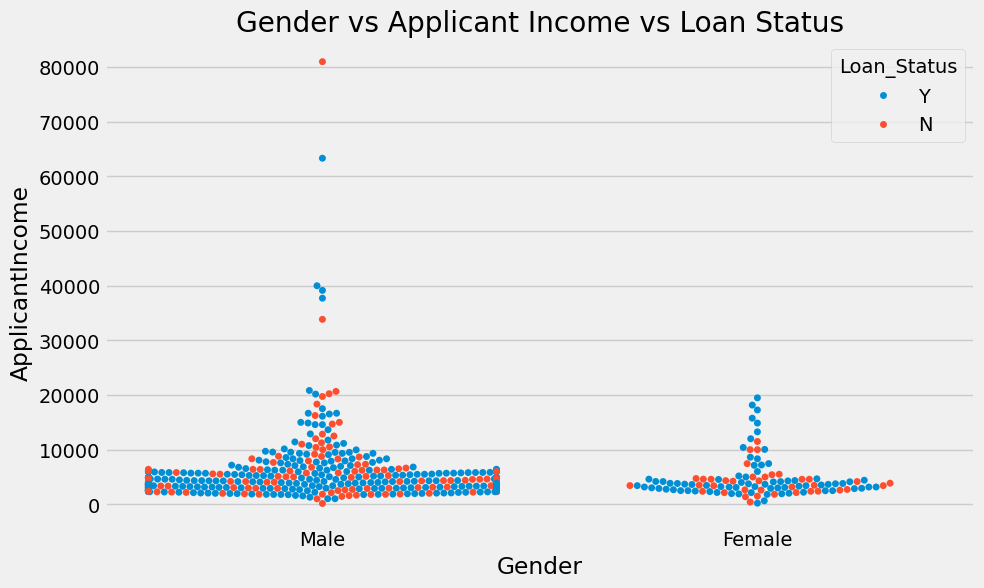

In [66]:
# =====================================
# Multivariate Analysis
# =====================================

plt.figure(figsize=(10,6))

sns.swarmplot(
    data=df,
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status'
)

plt.title("Gender vs Applicant Income vs Loan Status")
plt.show()

### Observations

- Male applicants generally have higher applicant income.
- Loan approval depends on both income and gender.
- Approved and rejected applications overlap across income levels.
- Swarmplot helps visualize the relationship among multiple variables.

# Checking and Handling Values

In [67]:
# =====================================
# Handling Categorical Values
# =====================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("Categorical values encoded successfully")
df.head()

Categorical values encoded successfully


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [68]:
# =====================================
# Handling Missing Values
# =====================================

print("Missing Values Before:")
print(df.isnull().sum())

# Fill categorical columns with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill numerical column with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

print("\nMissing Values After:")
print(df.isnull().sum())

Missing Values Before:
Loan_ID               0
Gender                0
Married               0
Dependents           15
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Missing Values After:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [69]:
# =====================================
# Verify Dataset
# =====================================

df.info()

print("\nShape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 62.5+ KB

Shape: (614, 13)


# Balancing the Dataset

In [70]:
!pip install imbalanced-learn -q

In [71]:
# =====================================
# Creating Features and Target
# =====================================

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


In [72]:
# Convert Dependents column

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'])

print(df['Dependents'].unique())

[0 1 2 3]


In [73]:
print(df.dtypes)

Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [74]:
X = df.drop(['Loan_ID','Loan_Status'], axis=1)
y = df['Loan_Status']

In [75]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X, y)

print(y.value_counts())
print(y_bal.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [76]:
# =====================================
# Balancing the Dataset using SMOTE
# =====================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X, y)

print("Before Balancing")
print(y.value_counts())

print("\nAfter Balancing")
print(y_bal.value_counts())

Before Balancing
Loan_Status
1    422
0    192
Name: count, dtype: int64

After Balancing
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [77]:
balanced_df = pd.DataFrame(X_bal, columns=X.columns)
balanced_df["Loan_Status"] = y_bal

balanced_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# Scaling the Data

In [78]:
# =====================================
# Scaling the Data
# =====================================

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale only the input features
X_scaled = scaler.fit_transform(X_bal)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling completed successfully.")
X_scaled.head()

Scaling completed successfully.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.482252,-1.154106,-0.688215,-0.489238,-0.382812,0.111702,-0.584610,-0.208439,0.287946,0.574053,1.360038
1,0.482252,0.841930,0.373674,-0.489238,-0.382812,-0.119063,-0.024552,-0.208439,0.287946,0.574053,-1.196470
2,0.482252,0.841930,-0.688215,-0.489238,1.728911,-0.407610,-0.584610,-0.979885,0.287946,0.574053,1.360038
3,0.482252,0.841930,-0.688215,2.043995,-0.382812,-0.483620,0.291131,-0.307980,0.287946,0.574053,1.360038
4,0.482252,-1.154106,-0.688215,-0.489238,-0.382812,0.139226,-0.584610,-0.046684,0.287946,0.574053,1.360038


In [79]:
X_scaled.describe().round(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00,844.00
mean,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.75,-1.15,-0.69,-0.49,-0.38,-0.93,-0.58,-1.69,-5.25,-1.97,-1.20
25%,0.48,-1.15,-0.69,-0.49,-0.38,-0.43,-0.58,-0.51,0.29,-0.21,-1.20
50%,0.48,0.84,-0.69,-0.49,-0.38,-0.27,-0.19,-0.21,0.29,0.57,0.08
75%,0.48,0.84,0.37,-0.49,-0.38,0.09,0.27,0.20,0.29,0.57,1.36
max,2.72,2.84,2.50,2.04,3.84,13.81,14.89,6.91,2.20,0.57,1.36


In [80]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


# Splitting Data into Training and Test Sets

In [81]:
# =====================================
# Splitting Data into Training and Test Sets
# =====================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_bal,
    test_size=0.33,
    random_state=42
)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (565, 11)
Testing Feature Shape  : (279, 11)
Training Target Shape  : (565,)
Testing Target Shape   : (279,)


In [82]:
# Display Shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (565, 11)
X_test : (279, 11)
y_train: (565,)
y_test : (279,)


# Decision Tree Model

In [83]:
# =====================================
# Decision Tree Model
# =====================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

# Predictions
y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", round(train_accuracy * 100, 2), "%")
print("Testing Accuracy  :", round(test_accuracy * 100, 2), "%")

Training Accuracy : 100.0 %
Testing Accuracy  : 79.93 %


In [84]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[112  36]
 [ 20 111]]


In [85]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.76      0.80       148
           1       0.76      0.85      0.80       131

    accuracy                           0.80       279
   macro avg       0.80      0.80      0.80       279
weighted avg       0.80      0.80      0.80       279



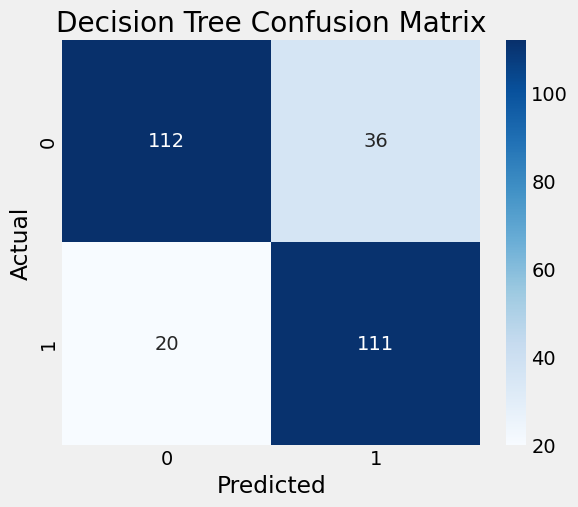

In [86]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observations

- Training Accuracy: 100%
- Testing Accuracy: 79.93%
- The model performs well on the training data but slightly overfits.
- Confusion matrix and classification report indicate satisfactory classification performance.

# Random Forest Model

In [87]:
# =====================================
# Random Forest Model
# =====================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

# Predictions
y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

# Accuracy
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("Training Accuracy :", round(train_accuracy_rf * 100, 2), "%")
print("Testing Accuracy  :", round(test_accuracy_rf * 100, 2), "%")

Training Accuracy : 100.0 %
Testing Accuracy  : 78.85 %


In [88]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_test_pred_rf)

print("Confusion Matrix")
print(cm_rf)

Confusion Matrix
[[105  43]
 [ 16 115]]


In [89]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.71      0.78       148
           1       0.73      0.88      0.80       131

    accuracy                           0.79       279
   macro avg       0.80      0.79      0.79       279
weighted avg       0.80      0.79      0.79       279



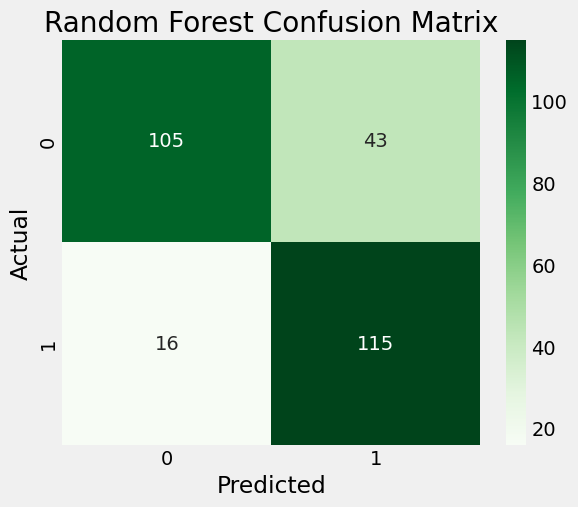

In [90]:
# =====================================
# Confusion Matrix Heatmap
# =====================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observations

- Random Forest combines multiple decision trees to improve prediction accuracy.
- It generally reduces overfitting compared to a single Decision Tree.
- The confusion matrix and classification report indicate the model's classification performance.
- Compare the testing accuracy with the Decision Tree to determine which model performs better.

# KNN Model

In [91]:
# =====================================
# KNN Model
# =====================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

# Predictions
y_train_pred_knn = knn.predict(X_train)
y_test_pred_knn = knn.predict(X_test)

# Accuracy
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)

print("Training Accuracy :", round(train_accuracy_knn * 100, 2), "%")
print("Testing Accuracy  :", round(test_accuracy_knn * 100, 2), "%")

Training Accuracy : 82.3 %
Testing Accuracy  : 69.53 %


In [92]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_test_pred_knn)

print("Confusion Matrix")
print(cm_knn)

Confusion Matrix
[[ 91  57]
 [ 28 103]]


In [93]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred_knn))

              precision    recall  f1-score   support

           0       0.76      0.61      0.68       148
           1       0.64      0.79      0.71       131

    accuracy                           0.70       279
   macro avg       0.70      0.70      0.69       279
weighted avg       0.71      0.70      0.69       279



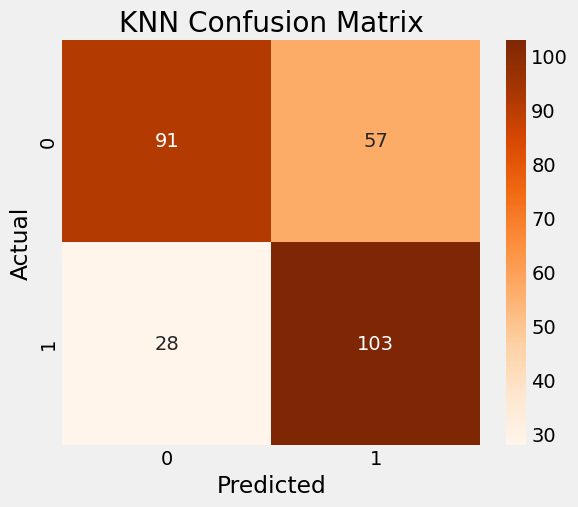

In [94]:
# =====================================
# Confusion Matrix Heatmap
# =====================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observations

- KNN classifies samples based on the nearest neighboring data points.
- Model performance depends on the selected value of K.
- The confusion matrix and classification report provide insight into prediction accuracy.
- Compare the testing accuracy with the previous models to identify the better-performing classifier.

# XGBoost Model (Gradient Boosting)

In [95]:
# =====================================
# XGBoost Model (Gradient Boosting)
# =====================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

xgb_model = GradientBoostingClassifier(random_state=42)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Accuracy
train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)

print("Training Accuracy :", round(train_accuracy_xgb*100,2),"%")
print("Testing Accuracy :", round(test_accuracy_xgb*100,2),"%")

Training Accuracy : 92.92 %
Testing Accuracy : 78.14 %


In [96]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

print(cm_xgb)

[[ 99  49]
 [ 12 119]]


In [97]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.67      0.76       148
           1       0.71      0.91      0.80       131

    accuracy                           0.78       279
   macro avg       0.80      0.79      0.78       279
weighted avg       0.81      0.78      0.78       279



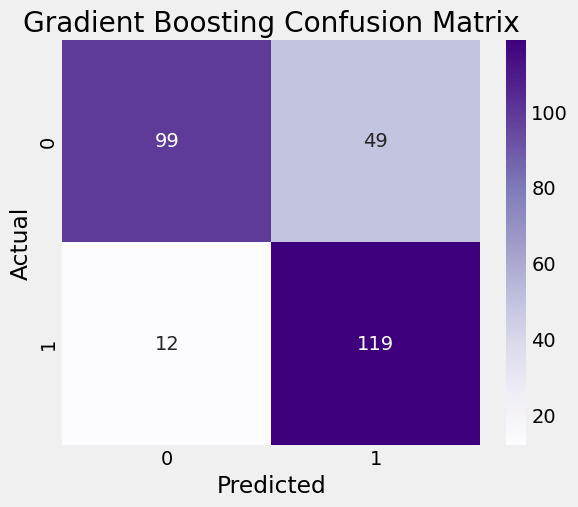

In [98]:
# =====================================
# Heatmap
# =====================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observations

- Gradient Boosting combines multiple weak learners to improve prediction accuracy.
- It generally performs better than a single Decision Tree.
- The confusion matrix and classification report show the model's effectiveness.
- Compare this model with the previous three models before selecting the final model.

# Evaluating Performance and Saving the Model

In [99]:
# =====================================
# Model Comparison
# =====================================

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],
    "Training Accuracy": [
        train_accuracy,
        train_accuracy_rf,
        train_accuracy_knn,
        train_accuracy_xgb
    ],
    "Testing Accuracy": [
        test_accuracy,
        test_accuracy_rf,
        test_accuracy_knn,
        test_accuracy_xgb
    ]
})

results["Training Accuracy"] = (results["Training Accuracy"] * 100).round(2)
results["Testing Accuracy"] = (results["Testing Accuracy"] * 100).round(2)

results

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,100.00,79.93
1,Random Forest,100.00,78.85
2,KNN,82.30,69.53
3,Gradient Boosting,92.92,78.14


In [100]:
import joblib

joblib.dump(decision_tree, "model.pkl")

print("Best model saved as model.pkl")

Best model saved as model.pkl


In [101]:
results.to_csv("model_comparison.csv", index=False)

print("Comparison table saved.")

Comparison table saved.


# Evaluating Performance and Saving the Model

In [102]:
# =====================================
# Model Comparison
# =====================================

import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],
    "Training Accuracy":[
        train_accuracy,
        train_accuracy_rf,
        train_accuracy_knn,
        train_accuracy_xgb
    ],
    "Testing Accuracy":[
        test_accuracy,
        test_accuracy_rf,
        test_accuracy_knn,
        test_accuracy_xgb
    ]
})

results["Training Accuracy"] *=100
results["Testing Accuracy"] *=100

results.round(2)

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,100.00,79.93
1,Random Forest,100.00,78.85
2,KNN,82.30,69.53
3,Gradient Boosting,92.92,78.14


In [103]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    decision_tree,
    X_scaled,
    y_bal,
    cv=5
)

print("Cross Validation Scores")
print(scores)

print("\nAverage Accuracy :", scores.mean())

Cross Validation Scores
[0.71005917 0.71597633 0.81656805 0.80473373 0.7797619 ]

Average Accuracy : 0.7654198365736826


In [104]:
import pickle

pickle.dump(decision_tree, open("model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [105]:
import os

print(os.listdir())

['.config', 'model.pkl', 'loan_prediction.xlsx', 'model_comparison.csv', 'loan_prediction.csv', 'scaler.pkl', '.ipynb_checkpoints', 'drive', 'sample_data']


In [107]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
import shutil
import os

destination = "/content/drive/MyDrive/SmartLender"

os.makedirs(destination, exist_ok=True)

# Copy files if they exist
for file in [
    "loan_prediction.csv",
    "model.pkl",
    "scaler.pkl",
    "model_comparison.csv"
]:
    if os.path.exists(file):
        shutil.copy(file, destination)

print("Files copied successfully.")

Files copied successfully.


In [109]:
import os

os.listdir("/content/drive/MyDrive/SmartLender")


['Loan_Prediction.ipynb',
 'loan_prediction.csv',
 'loan_prediction.xlsx',
 'model.pkl',
 'scaler.pkl',
 'model_comparison.csv']